# 2.4 Современные тенденции и вызовы в ИИ

Задание: **Вариант 3. Создание текстового описания изображения**

Используйте модель для генерации подписей к изображениям (например, BLIP или ViT-GPT2). Загрузите несколько изображений и сгенерируйте для каждого текстовое описание.

---

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic


Изображение: image1.jpg


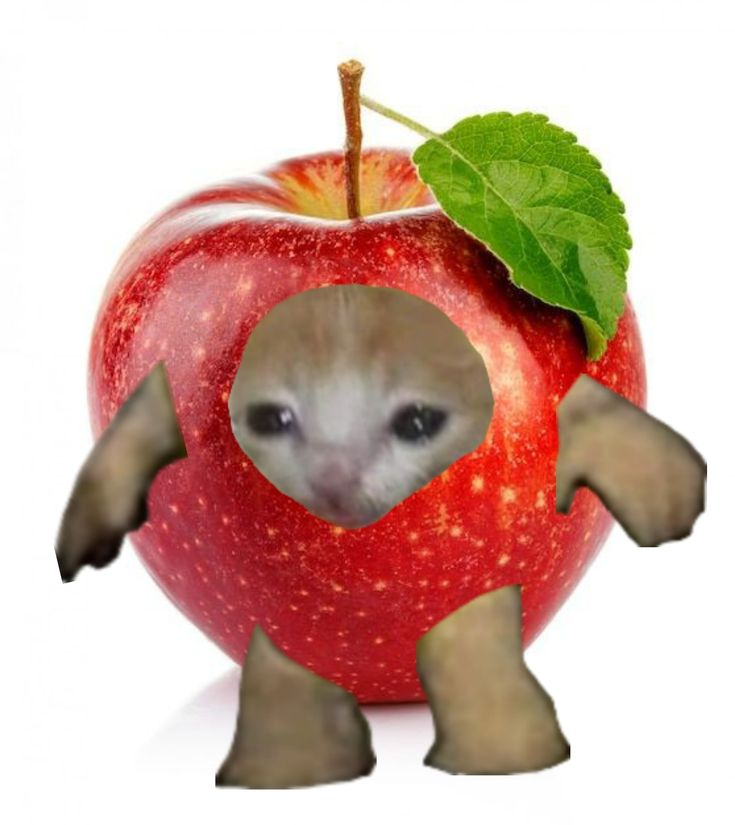

Сгенерированное описание: a mouse in an apple

Изображение: image2.jpg


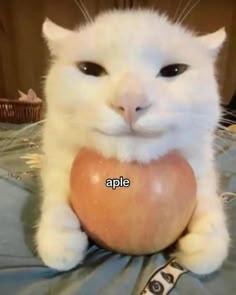

Сгенерированное описание: a cat sitting on top of a bed holding an apple


model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

In [2]:
import torch
from transformers import BlipProcessor, BlipForConditionalGeneration
from IPython.display import display
from PIL import Image
import os

model_name = "Salesforce/blip-image-captioning-base"

processor = BlipProcessor.from_pretrained(model_name)
model = BlipForConditionalGeneration.from_pretrained(model_name)

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

image_paths = [
    "image1.jpg",
    "image2.jpg"
]

for path in image_paths:
    if not os.path.exists(path):
        print(f"Файл {path} не найден")
        continue

    image = Image.open(path).convert("RGB")

    inputs = processor(images=image, return_tensors="pt").to(device)

    with torch.no_grad():
        output = model.generate(**inputs, max_length=50)

    caption = processor.decode(output[0], skip_special_tokens=True)

    print(f"\nИзображение: {path}")
    display(image)
    print(f"Сгенерированное описание: {caption}")